In [1]:
!pip install mlflow 

In [2]:
# test  mlflow
import mlflow 
import setup_up
import os 

SERVER_URL = os.environ["SERVER_URL"]

mlflow.set_tracking_uri(SERVER_URL)

with mlflow.start_run():
    mlflow.log_param('param1',15)
    mlflow.log_metric('metric1',0.89)

/home/grayfog/miniconda3/envs/YTsentimentAnalyzer/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


In [3]:
#creating baseline model
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('../data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [5]:
df.dropna(inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df[~(df['clean_comment'].str.strip() == '')]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [8]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 

In [9]:
# ensure necessary NLTK data is downloaded 
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/grayfog/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/grayfog/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
def preprocess_comment(comment):
    comment = comment.lower()
    # remove trailing whitespaces
    comment = comment.strip()

    comment = re.sub(r'\n',' ', comment)

    # remove non-alphanumeric characters, except punctation 
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', '', comment)

    # Remove stopwords but retain import ones 
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])

    # lemmatize the words 
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [11]:
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

In [12]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [13]:
import mlflow
import mlflow.sklearn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [14]:
# vectorize the comments using bag of words  
vectorizer = CountVectorizer(max_features=1000)

In [15]:
X = vectorizer.fit_transform(df['clean_comment']).toarray()
y = df['category'] # assuming sentiment is the target variable (0 or 1 for binary)

In [16]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(36799, 1000))

In [17]:
X.shape

(36799, 1000)

In [18]:
y.shape

(36799,)

In [19]:
mlflow.set_tracking_uri("SERVER_URL")

In [20]:
mlflow.set_experiment("Baseline RF")

/home/grayfog/miniconda3/envs/YTsentimentAnalyzer/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/03/14 23:38:47 INFO mlflow.tracking.fluent: Experiment with name 'Baseline RF' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/grayfog/YTSentiment/notebooks/SERVER_URL/123874282665700657', creation_time=1773527927928, experiment_id='123874282665700657', last_update_time=1773527927928, lifecycle_stage='active', name='Baseline RF', tags={}>

In [21]:
!pip install boto3

In [22]:
!pip install awscli

In [23]:
import os 
print(os.getenv("AWS_DEFAULT_REGION"))
print(bool(os.getenv("AWS_ACCESS_KEY_ID")))
print(bool(os.getenv("AWS_SECRET_ACCESS_KEY")))

eu-north-1
True
True


In [24]:
!aws sts get-caller-identity > /dev/null

/home/grayfog/miniconda3/envs/YTsentimentAnalyzer/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Accuracy 0.658695652173913


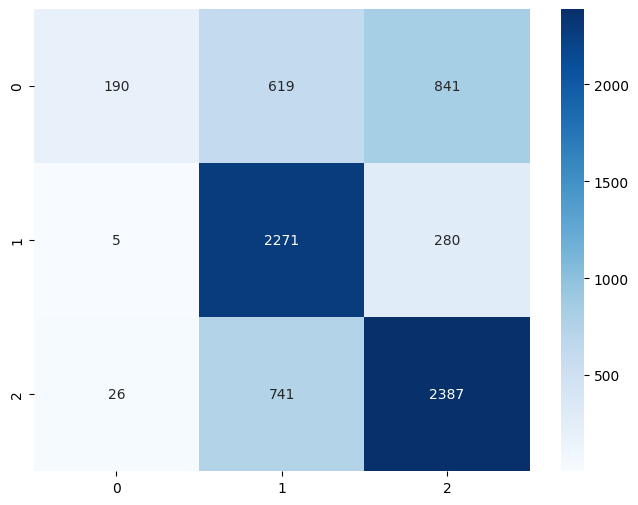

In [25]:
# splt the data into training and testing sets (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
mlflow.end_run()

with mlflow.start_run() as run:
    mlflow.set_tag('mlflow.runName', 'RandomForest_Baseline_TrainTestSplit')
    mlflow.set_tag('experiment_type', 'baseline')
    mlflow.set_tag('model_type', "RandomForestClassifier")

    mlflow.set_tag('desctiption','Baseline RandomForest model for sentiment analysis using Bag of words (BoW)')

    mlflow.log_param('vectorizer_type', 'CountVectorizer')
    mlflow.log_param('vectorizer_max_features',vectorizer.max_features)

    # log RF parameters 
    n_estimators = 200 
    max_depth = 15

    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_param('max_depth', max_depth)

    # initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    # Make predictions on the test set 
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy 
    accuracy = accuracy_score(y_test,y_pred)
    mlflow.log_metric('accuracy', accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics,dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f'{label}_{metric}',value)
                
    # confusion matrix plot 
    conf_matrix = confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(conf_matrix, annot=True,fmt='d',cmap='Blues')
    plt.xlabel = 'Predicted'
    plt.ylabel = 'actual'
    plt.title = 'confusion matrix'

    # save and log the confusion matrix 
    from pathlib import Path
    plt.savefig('../data/confusion_matrix_exp2.png')
    mlflow.log_artifact('../data/confusion_matrix_exp2.png')

    # log the RF model
    mlflow.sklearn.log_model(model, name='random_forest_model')

    df.to_csv('../data/dataset.csv',index=False)
    mlflow.log_artifact('../data/dataset.csv')

print(f'Accuracy {accuracy}')

In [26]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

          -1       0.86      0.12      0.20      1650
           0       0.63      0.89      0.73      2556
           1       0.68      0.76      0.72      3154

    accuracy                           0.66      7360
   macro avg       0.72      0.59      0.55      7360
weighted avg       0.70      0.66      0.61      7360



In [27]:
df.to_csv('../data/read_preprocessing.csv')

In [28]:
pd.read_csv('../data/read_preprocessing.csv').head()

,Unnamed: 0,clean_comment,category
0,0,family mormon never tried explain still stare ...,1
1,1,buddhism much lot compatible christianity espe...,1
2,2,seriously say thing first get complex explain ...,-1
3,3,learned want teach different focus goal not wr...,0
4,4,benefit may want read living buddha living chr...,1
